# Notebook 1: Feature Extraction (Transfer Learning — Phase 1)

## What we're doing
Take a ResNet18 pretrained on **ImageNet** (cars, dogs, keyboards, etc.) and use it
as a **fixed feature extractor** to classify **flowers** — images it has NEVER seen.

## Why this works
Early CNN layers learn **universal visual features**:
- Layer 1: edges, gradients
- Layer 2: textures, patterns
- Layer 3: object parts
- Layer 4: high-level shapes

These features are useful for ANY image task. We only need to train a small
classification head that maps these features → flower species.

## What's frozen
**Everything** except the new classification head. We're training ~157K parameters
out of ~11.3M total (~1.4%).

In [10]:
import sys
sys.path.insert(0, '..')

import torch
from src.data import get_dataloaders
from src.model import create_model, count_parameters
from src.train import train_model
from src.evaluate import plot_training_history, get_predictions, plot_confusion_matrix

In [11]:
# ---- Configuration ----
DEVICE = (
    'mps' if torch.backends.mps.is_available()     # Apple Silicon
    else 'cuda' if torch.cuda.is_available()        # NVIDIA GPU
    else 'cpu'
)
print(f'Using device: {DEVICE}')

BATCH_SIZE = 32
NUM_EPOCHS = 15
LEARNING_RATE = 1e-1  # Relatively high — we're only training a small head

Using device: mps


In [12]:
# ---- Load Data ----
train_loader, val_loader, test_loader = get_dataloaders(
    data_dir='../data', batch_size=BATCH_SIZE
)

Train: 1020 images
Val:   1020 images
Test:  6149 images
Classes: 10 images/class avg, 102 classes


In [13]:
# ---- Create Model (Feature Extraction mode) ----
model = create_model(num_classes=102, mode='feature_extract')
model = model.to(DEVICE)

# See how few parameters we're actually training
count_parameters(model)

Total parameters:     11,334,054
Trainable parameters:    157,542  (1.4%)
Frozen parameters:    11,176,512  (98.6%)


(157542, 11334054)

In [14]:
# ---- Setup Optimizer ----
# Only optimize parameters that require gradients (the new head)
params_to_update = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params_to_update, lr=LEARNING_RATE)

# Step-decay scheduler: reduce LR by 0.1x every 7 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print(f'Optimizing {len(params_to_update)} parameter tensors')

Optimizing 4 parameter tensors


In [15]:
# ---- Train ----
history = train_model(
    model, train_loader, val_loader, DEVICE,
    optimizer=optimizer, scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    save_path='../models/feature_extract_best.pth'
)

Epoch  1/15 (43s) | Train Loss: 31.9222  Acc: 0.5% | Val Loss: 4.9415  Acc: 1.0% | LR: 1.00e-01
  ✓ Saved best model (val_acc: 1.0%)


Epoch  2/15 (37s) | Train Loss: 4.6830  Acc: 0.6% | Val Loss: 4.6343  Acc: 1.0% | LR: 1.00e-01


Epoch  3/15 (43s) | Train Loss: 4.6852  Acc: 0.4% | Val Loss: 4.6299  Acc: 1.0% | LR: 1.00e-01


Epoch  4/15 (37s) | Train Loss: 4.7032  Acc: 0.6% | Val Loss: 4.6294  Acc: 1.0% | LR: 1.00e-01


Epoch  5/15 (37s) | Train Loss: 4.6791  Acc: 0.5% | Val Loss: 4.6301  Acc: 1.0% | LR: 1.00e-01


...

Epoch 11/15 (31s) | Train Loss: 4.6465  Acc: 1.1% | Val Loss: 4.6259  Acc: 1.0% | LR: 1.00e-02


Epoch 12/15 (33s) | Train Loss: 4.6311  Acc: 1.0% | Val Loss: 4.6258  Acc: 1.0% | LR: 1.00e-02


Epoch 13/15 (26s) | Train Loss: 4.6303  Acc: 0.8% | Val Loss: 4.6254  Acc: 1.0% | LR: 1.00e-02


Epoch 14/15 (34s) | Train Loss: 4.6302  Acc: 0.5% | Val Loss: 4.6253  Acc: 1.0% | LR: 1.00e-02


Epoch 15/15 (32s) | Train Loss: 4.6336  Acc: 1.0% | Val Loss: 4.6253  Acc: 1.0% | LR: 1.00e-03

Best validation accuracy: 1.0%


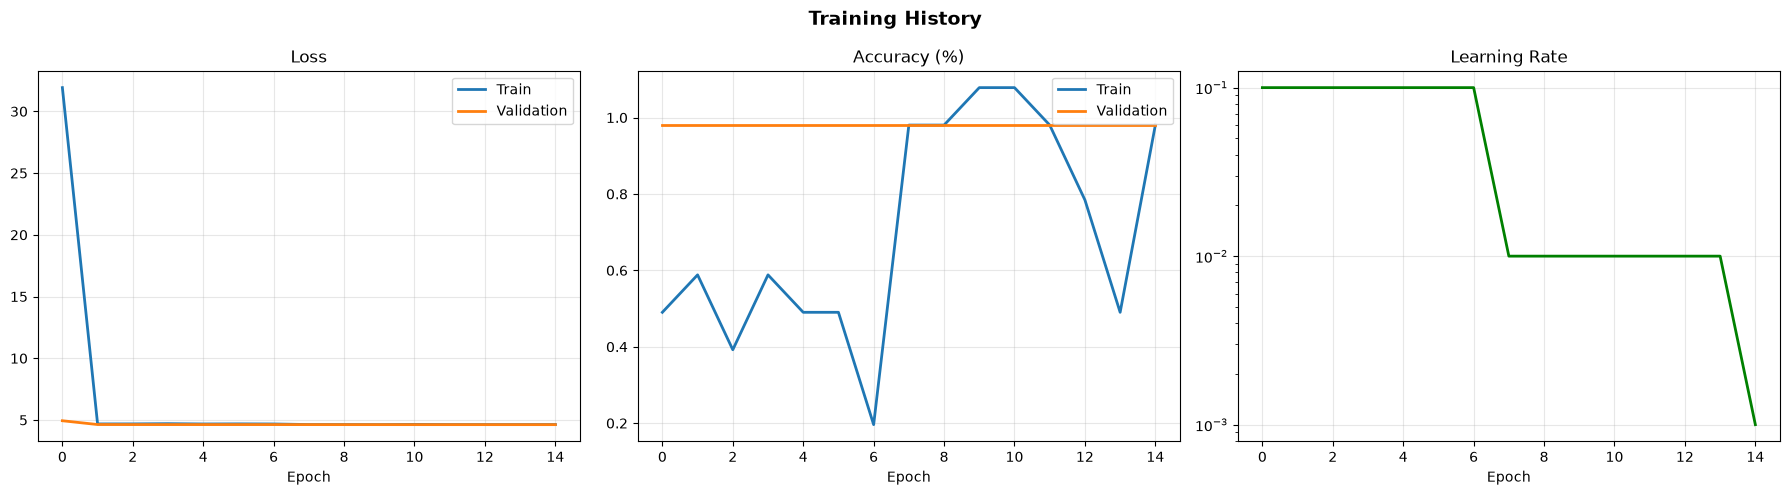

In [16]:
# ---- Plot Training Curves ----
# LOOK FOR:
# - Does val_acc plateau? That's the ceiling of feature extraction.
# - Is there a gap between train/val? That's overfitting.
plot_training_history(history, save_path='../results/feature_extract_curves.png')

In [17]:
# ---- Evaluate on Test Set ----
model.load_state_dict(torch.load('../models/feature_extract_best.pth', map_location=DEVICE))
preds, labels = get_predictions(model, test_loader, DEVICE)

test_acc = 100.0 * (preds == labels).mean()
print(f'\nTest Accuracy: {test_acc:.1f}%')
print(f'\nRemember: this model was trained on ImageNet (everyday objects).')
print(f'It has NEVER seen flower images during pretraining.')
print(f'Yet it achieves {test_acc:.1f}% on 102 flower species!')

Evaluating: 100%|████████████| 193/193 [00:40<00:00,  4.80it/s]


Test Accuracy: 0.8%

Remember: this model was trained on ImageNet (everyday objects).
It has NEVER seen flower images during pretraining.
Yet it achieves 0.8% on 102 flower species!


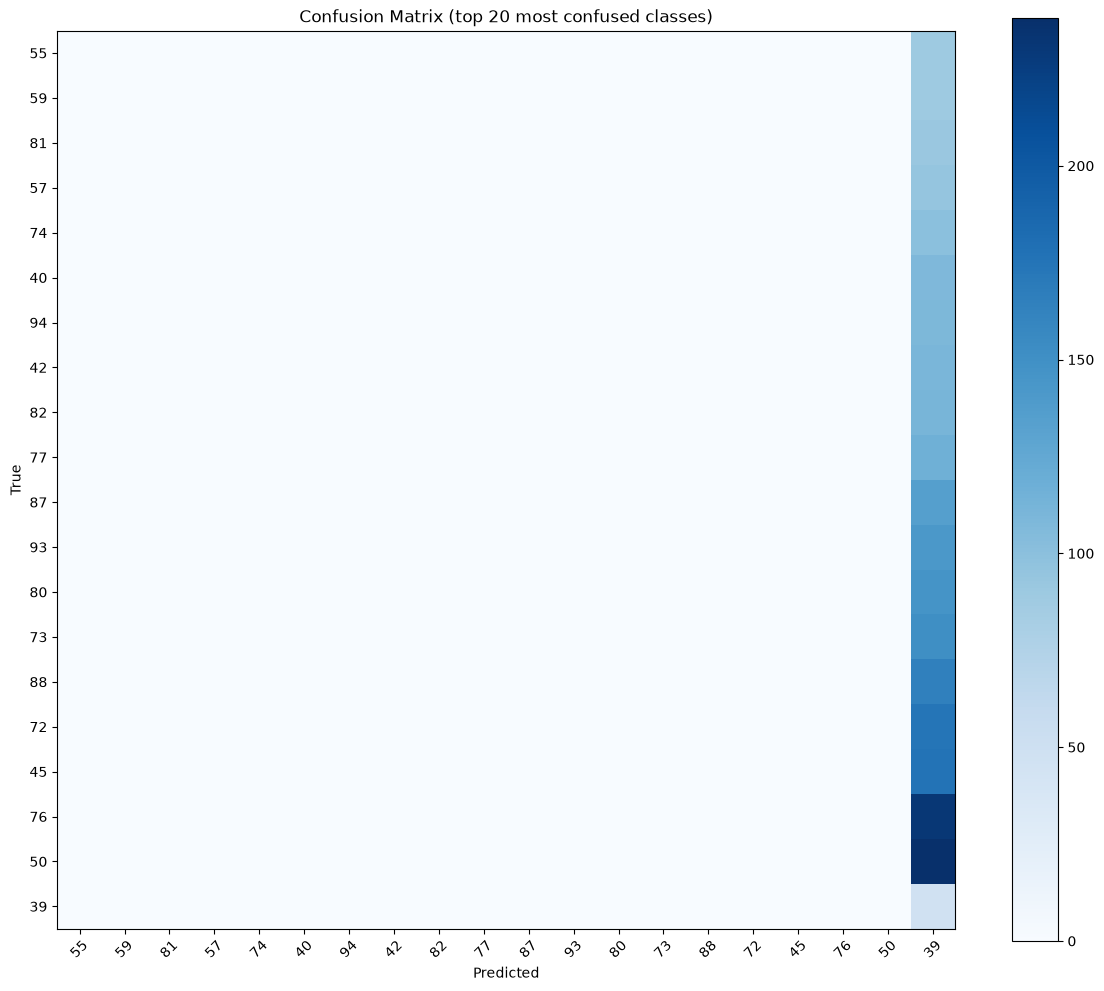

In [18]:
# ---- Confusion Matrix ----
plot_confusion_matrix(preds, labels, save_path='../results/feature_extract_confusion.png')

## Key Takeaways

1. **Feature extraction works** — even without training the backbone, we get
   reasonable accuracy on a domain the model never saw
2. **But there's a ceiling** — the frozen features aren't perfectly adapted to
   flowers. Fine-tuning (Notebook 2) will push accuracy higher.
3. **We trained <2% of the parameters** — this is extremely efficient

→ **Next: Notebook 02** — unfreeze backbone layers and fine-tune